# Impute Missing Data and Research Question
- Author: Bryan Bravo
- Created: 2026-04-07
## Research Question:
Can these indicators (oil prices, LSCI, GPR, events, CPI, rates, FX) forecast near-term changes in a country's FX reserves for treasury/planning decisions?

### Selected Variables
#### Relative (Target) Variable:
- **fx_reserves**: Continuous Variable

#### Explanatory Variables:
- **country**: Categorical Variable
- **date**: Categorical Variable
- **interest_rate**: Continuous Variable
- **fx_rate**: Continuous Variable
- **brent_dollars_per_barrel**: Continuous Variable
- **wti_dollars_per_barrel**: Continuous Variable
- **events**: Continuous Variable
- **cpi**: Continuous Variable
- **gpr_index**: Continuous Variable
- **lsci**: Continuous Variable

## Import Libraries

In [1]:
import os
import sys

os.chdir("C:/Users/bravo/OneDrive/bravo_projects/MLProject/ml_missing_value_impute")
# Set JAVA_HOME before importing PySpark and use findspark
os.environ['JAVA_HOME'] = r'C:\Program Files\Java\jdk-22'  # May need to remove or update in cloud environment.
import findspark
findspark.init()

import requests
import pandas as pd
import numpy as np
import json
import pyspark
from datetime import datetime as dt
from dateutil.relativedelta import relativedelta
from functools import reduce
from pyspark.sql import (
    functions as F,
    Window as W,
    types as T,
    SparkSession,
    DataFrame
)

# Visualize data for joined dataframes.
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn libraries and packages
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

# api keys and other hardcoded values for the Strait of Hormuz Research project.
# Note: In a production environment, these should be stored securely and not hardcoded.
import hardcoded_keys # Note: This file is added to .gitignore to prevent accidental commits of sensitive information.

import proj_vars

### Initialize Spark Session


In [2]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BusinessPlanAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.hadoop.io.native.lib.available", "false") \
    .config("spark.sql.parquet.nativeio.enabled", "false") \
    .getOrCreate()

print("Spark Session created successfully!")

Spark Session created successfully!


## Variables

In [3]:
end_date = (dt.now().replace(day=1) - relativedelta(days=1)).strftime("%Y-%m-%d")
# in_path = 's3a://ml-project-s3-bronze/input_folder/'
in_path = 'processed_datasets/'
out_path = 'processed_datasets/'


## User Defined Functions 

# Query

In [4]:
# Import dataset
joined_df = spark.read.csv(in_path + 'joined_input.csv', header=True, inferSchema=True)
joined_df = joined_df.withColumn('date', F.to_date(F.col('date'), 'yyyyMMdd'))

In [5]:
joined_df.toPandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60276 entries, 0 to 60275
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      60276 non-null  int32  
 1   month                     60276 non-null  int32  
 2   country                   60276 non-null  object 
 3   date                      60276 non-null  object 
 4   interest_rate             60276 non-null  float64
 5   fx_rate                   60276 non-null  float64
 6   brent_dollars_per_barrel  60276 non-null  float64
 7   wti_dollars_per_barrel    60276 non-null  float64
 8   events                    60276 non-null  int32  
 9   cpi                       60276 non-null  float64
 10  gpr_index                 60276 non-null  float64
 11  lsci                      60276 non-null  float64
 12  fx_reserves               55596 non-null  float64
dtypes: float64(8), int32(3), object(2)
memory usage: 5.3+ MB


## Data Wrangling
### One-hot encode `month` variable, and add a one-hot encoded variable for day-of-week.


In [6]:
# Extract country values
country_list = joined_df.select(F.col('country')).distinct().toPandas()['country'].tolist()

wrangled_df = (
    joined_df
    .withColumns({  # One-hot encode month column
        f"month_{i}": F.when(F.col('month') == i, F.lit(1)).otherwise(F.lit(0)) for i in range(1, 13)
    })
    .withColumns({  # Generate a day of week one-hot encoding (1-7, where 1 = Sunday and 7 = Saturday)
        f'dow_{i}': F.when(F.dayofweek(F.col('date')) == i, F.lit(1)).otherwise(F.lit(0)) for i in range(1, 8)
    })
    .drop('month', 'date')
)


In [7]:
for country in country_list:
    print(f"Creating {country}_df and {country}_null_df")
    globals()[f"{country}_df"] = (
        wrangled_df
        .filter(F.col('fx_reserves').isNotNull() 
                & F.col('country').contains(country))
        .drop('country')
    ).toPandas()
    globals()[f"{country}_null_df"] = (
        wrangled_df
        .filter(F.col('fx_reserves').isNull() 
                & F.col('country').contains(country))
        .drop('country')
    ).toPandas()

Creating brazil_df and brazil_null_df
Creating canada_df and canada_null_df
Creating japan_df and japan_null_df
Creating china_df and china_null_df
Creating australia_df and australia_null_df
Creating germany_df and germany_null_df
Creating india_df and india_null_df
Creating mexico_df and mexico_null_df
Creating france_df and france_null_df
Creating italy_df and italy_null_df
Creating south_africa_df and south_africa_null_df
Creating russia_df and russia_null_df
Creating south_korea_df and south_korea_null_df
Creating turkiye_df and turkiye_null_df
Creating united_kingdom_df and united_kingdom_null_df
Creating united_states_df and united_states_null_df


### Feature Selection using SelectKBest
`fx_reserves` response variable

In [8]:
# Find best features
for country in country_list:
    print(f"Creating '{country}_selected_features'")
    # Define Variables
    response_var = 'fx_reserves'
    explanatory_var = [var for var in globals()[f'{country}_df'].columns if var not in ['fx_reserves']]

    # Assign values
    X = globals()[f'{country}_df'][explanatory_var]
    y = globals()[f'{country}_df'][response_var]

    # Use SelectKBest
    skbest = SelectKBest(k='all', score_func=f_regression)
    X_skbest = skbest.fit_transform(X, y)
    
    # Finding p-values and dataframe creation.
    pval_df = pd.DataFrame({
        'feature': X.columns,
        'p_value': skbest.pvalues_
    }).sort_values('p_value')

    pval_df = pval_df[pval_df['p_value'] < 0.05]
    globals()[f"{country}_selected_features"] = pval_df['feature'].tolist()


Creating 'brazil_selected_features'
Creating 'canada_selected_features'
Creating 'japan_selected_features'
Creating 'china_selected_features'
Creating 'australia_selected_features'
Creating 'germany_selected_features'
Creating 'india_selected_features'
Creating 'mexico_selected_features'
Creating 'france_selected_features'
Creating 'italy_selected_features'
Creating 'south_africa_selected_features'
Creating 'russia_selected_features'
Creating 'south_korea_selected_features'
Creating 'turkiye_selected_features'
Creating 'united_kingdom_selected_features'
Creating 'united_states_selected_features'


# Machine Learning
## `fx_reserves`
### Random Forest Regression Model for `fx_reserves`

In [9]:
for country in country_list:

    print(f"Creating RF model: {country}_rf_mdl")
    response_var = 'fx_reserves'
    explanatory_var = globals()[f'{country}_selected_features']

    # Assign values
    X = globals()[f"{country}_df"][explanatory_var]
    y = globals()[f"{country}_df"][response_var]

    seed = 2026
    ## Train/Test Split

    globals()[f"{country}_X_train"], globals()[f"{country}_X_test"], globals()[f"{country}_y_train"], globals()[f"{country}_y_test"] = (
        train_test_split(X, y, test_size=0.2, random_state=seed)
        )

    # Instantiate Random Forest Regressor and KFold for cross_validation
    rf = RandomForestRegressor(random_state=seed)
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    # Define a grid of hyperparameters
    params = {
        'n_estimators': np.arange(50, 100, 25),  # Number of trees
        'max_depth': np.arange(5, 50, 5),  # The maximum depth of the tree
        'max_features': ['log2', 'sqrt']  # Amount of features to consider when looking to split
    }

    # Instantiate GridSearchCV
    grid_rf = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv=kf,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1)
    # Fit Training set
    grid_rf.fit(globals()[f"{country}_X_train"], globals()[f"{country}_y_train"])

    # Extract Best Score
    best_score = grid_rf.best_score_
    print(f"Best Negative MSE Score ({country}): {best_score:.2f}")

    # Extract the best hyperparameters
    best_hyperparams = grid_rf.best_params_
    print(f'Best Hyperparameters: \n {best_hyperparams} \n')

    # Extract the best model
    globals()[f'{country}_rf_mdl'] = grid_rf.best_estimator_

Creating RF model: brazil_rf_mdl
Best Negative MSE Score (brazil): -365729.35
Best Hyperparameters: 
 {'max_depth': np.int64(15), 'max_features': 'log2', 'n_estimators': np.int64(75)} 

Creating RF model: canada_rf_mdl
Best Negative MSE Score (canada): -61812.12
Best Hyperparameters: 
 {'max_depth': np.int64(25), 'max_features': 'log2', 'n_estimators': np.int64(75)} 

Creating RF model: japan_rf_mdl
Best Negative MSE Score (japan): -2660905.96
Best Hyperparameters: 
 {'max_depth': np.int64(20), 'max_features': 'log2', 'n_estimators': np.int64(50)} 

Creating RF model: china_rf_mdl
Best Negative MSE Score (china): -44589294.84
Best Hyperparameters: 
 {'max_depth': np.int64(30), 'max_features': 'log2', 'n_estimators': np.int64(75)} 

Creating RF model: australia_rf_mdl
Best Negative MSE Score (australia): -86509.79
Best Hyperparameters: 
 {'max_depth': np.int64(25), 'max_features': 'log2', 'n_estimators': np.int64(75)} 

Creating RF model: germany_rf_mdl
Best Negative MSE Score (germany)

#### Feature Importance

Features Importances: 
 cpi                         3.726402e-01
year                        3.182574e-01
lsci                        1.786820e-01
fx_rate                     6.268344e-02
interest_rate               4.134106e-02
wti_dollars_per_barrel      1.165891e-02
brent_dollars_per_barrel    1.019804e-02
gpr_index                   4.538156e-03
events                      8.865549e-07
dow_1                       1.482049e-19
dtype: float64


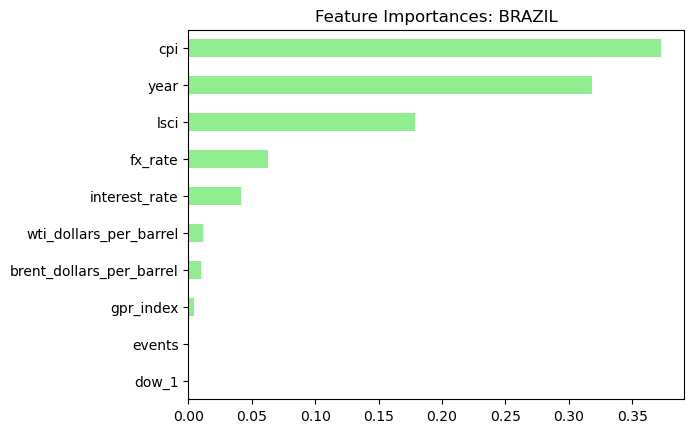

Features Importances: 
 cpi                         0.412233
year                        0.392869
fx_rate                     0.099778
lsci                        0.035440
brent_dollars_per_barrel    0.023389
wti_dollars_per_barrel      0.023201
gpr_index                   0.013088
events                      0.000002
dtype: float64


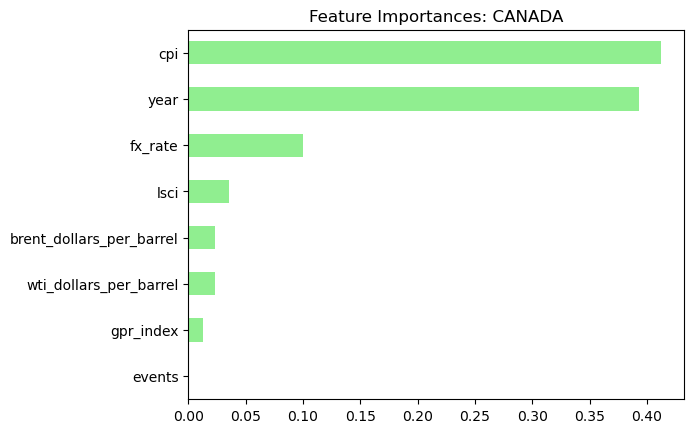

Features Importances: 
 lsci                        3.193837e-01
year                        3.044621e-01
interest_rate               2.007407e-01
cpi                         9.885437e-02
fx_rate                     4.588414e-02
wti_dollars_per_barrel      1.426700e-02
brent_dollars_per_barrel    1.265126e-02
gpr_index                   3.756691e-03
dow_1                       3.172222e-18
dtype: float64


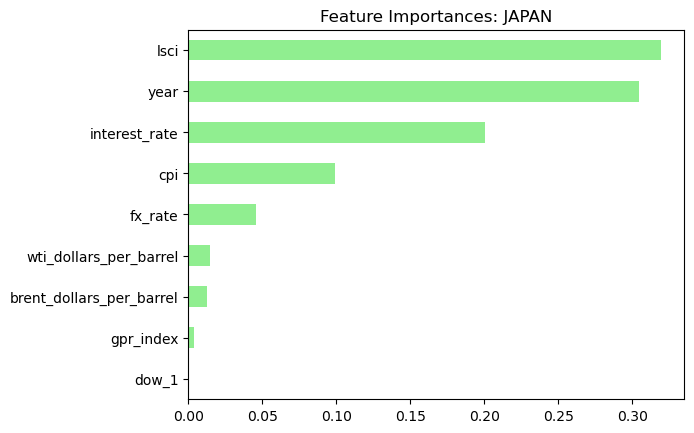

Features Importances: 
 lsci                        2.907242e-01
year                        2.544676e-01
cpi                         2.130930e-01
fx_rate                     1.139054e-01
interest_rate               1.030551e-01
gpr_index                   1.294415e-02
brent_dollars_per_barrel    1.165970e-02
month_4                     1.446218e-04
events                      6.259307e-06
dow_1                       7.632469e-08
dtype: float64


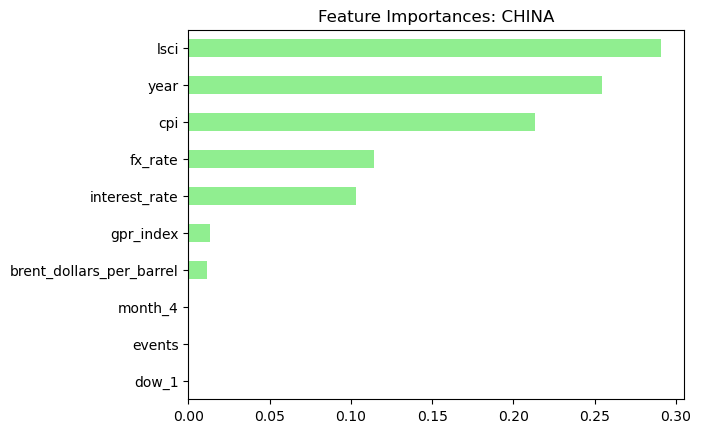

Features Importances: 
 cpi                       0.198732
interest_rate             0.184568
year                      0.163677
lsci                      0.130165
gpr_index                 0.104553
wti_dollars_per_barrel    0.088867
fx_rate                   0.072966
month_12                  0.008702
month_1                   0.007302
month_3                   0.006558
month_5                   0.006508
month_2                   0.006131
month_10                  0.005842
month_9                   0.004956
month_7                   0.004394
month_6                   0.003726
month_11                  0.002354
dtype: float64


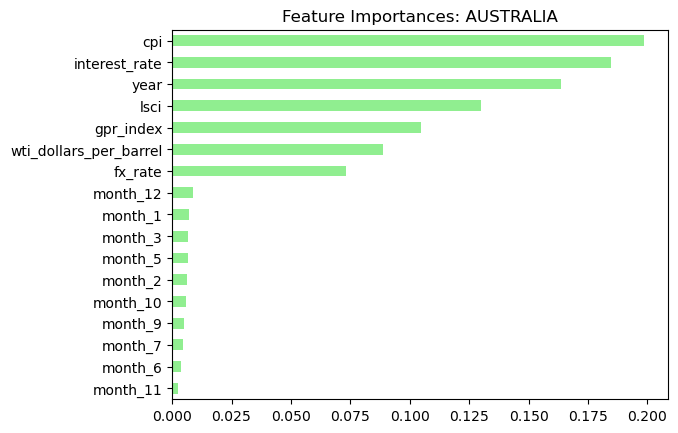

Features Importances: 
 cpi                         0.286663
year                        0.271934
lsci                        0.173691
interest_rate               0.082849
brent_dollars_per_barrel    0.049559
fx_rate                     0.042623
gpr_index                   0.036124
events                      0.028551
wti_dollars_per_barrel      0.028007
dtype: float64


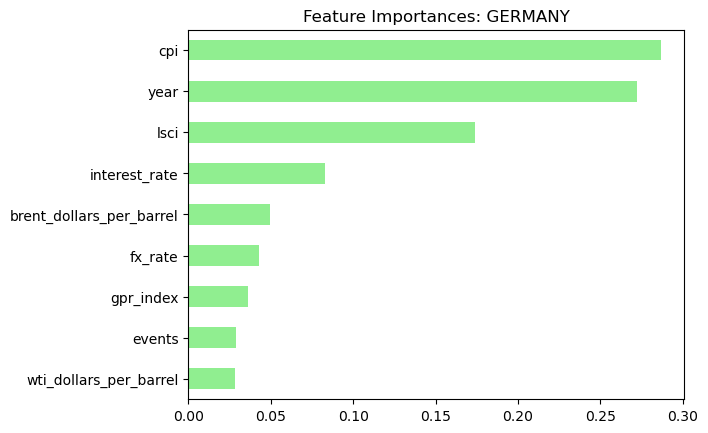

Features Importances: 
 cpi                         0.379614
year                        0.251160
fx_rate                     0.184910
lsci                        0.108108
interest_rate               0.050969
wti_dollars_per_barrel      0.013508
brent_dollars_per_barrel    0.008396
gpr_index                   0.003332
events                      0.000003
dtype: float64


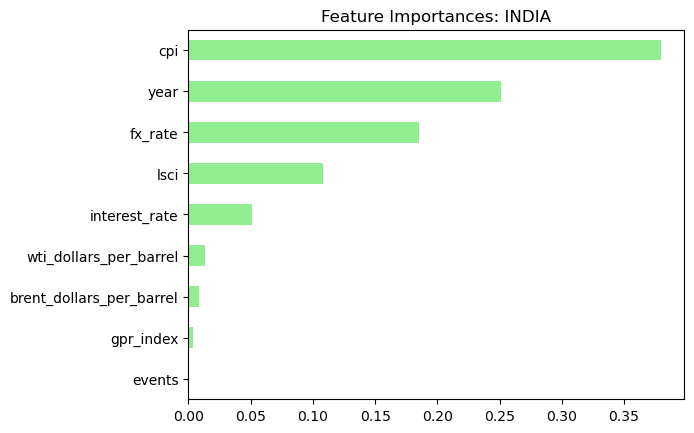

Features Importances: 
 cpi                         4.365041e-01
year                        2.548446e-01
lsci                        1.220444e-01
fx_rate                     1.136207e-01
interest_rate               5.438261e-02
brent_dollars_per_barrel    8.618684e-03
wti_dollars_per_barrel      6.579689e-03
gpr_index                   3.404782e-03
events                      4.696404e-07
dtype: float64


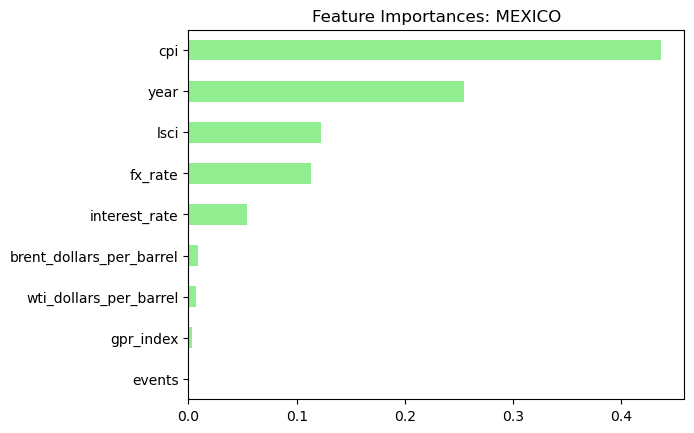

Features Importances: 
 cpi                         3.881369e-01
year                        2.296929e-01
lsci                        1.677118e-01
interest_rate               1.262532e-01
fx_rate                     5.006144e-02
brent_dollars_per_barrel    1.531038e-02
gpr_index                   1.236459e-02
wti_dollars_per_barrel      1.046845e-02
events                      3.430439e-07
dtype: float64


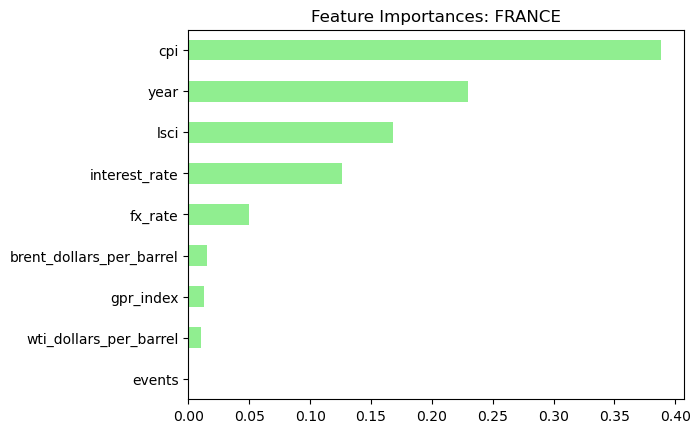

Features Importances: 
 cpi              0.292140
year             0.220546
events           0.157996
lsci             0.157483
interest_rate    0.105280
fx_rate          0.057480
gpr_index        0.009074
dtype: float64


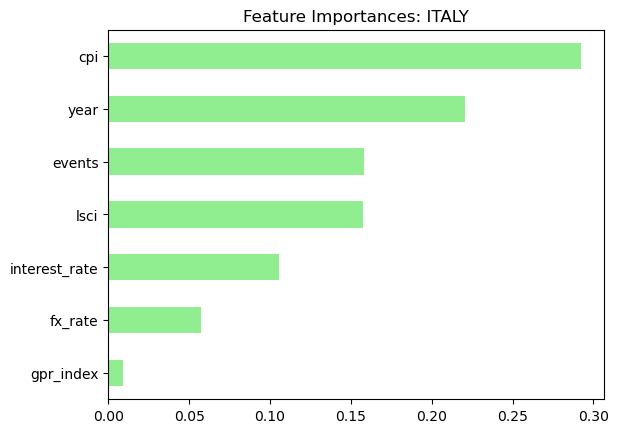

Features Importances: 
 cpi                         4.068302e-01
year                        2.513708e-01
interest_rate               1.183174e-01
fx_rate                     9.013169e-02
lsci                        8.714635e-02
brent_dollars_per_barrel    1.962097e-02
gpr_index                   1.508027e-02
wti_dollars_per_barrel      1.149103e-02
events                      1.127309e-05
dow_1                       1.400765e-09
dtype: float64


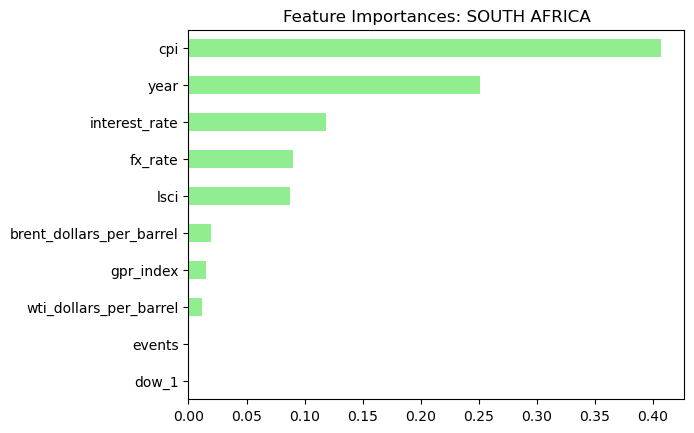

Features Importances: 
 wti_dollars_per_barrel      0.374999
brent_dollars_per_barrel    0.327464
interest_rate               0.297537
dtype: float64


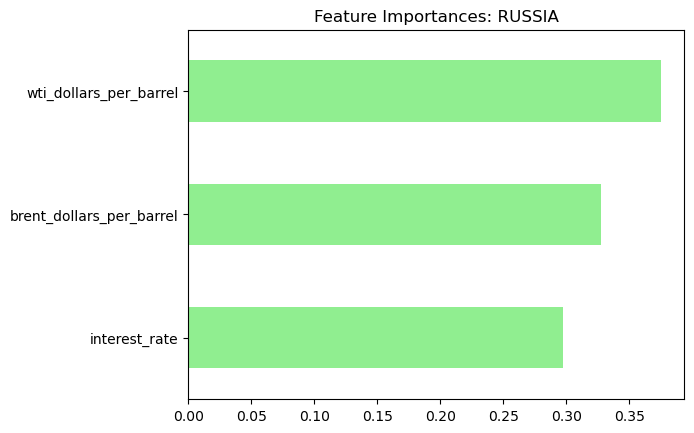

Features Importances: 
 cpi                         3.813162e-01
year                        2.411412e-01
lsci                        2.386917e-01
interest_rate               7.330500e-02
fx_rate                     3.333761e-02
brent_dollars_per_barrel    1.409123e-02
wti_dollars_per_barrel      1.270841e-02
gpr_index                   5.408571e-03
events                      7.879952e-08
dtype: float64


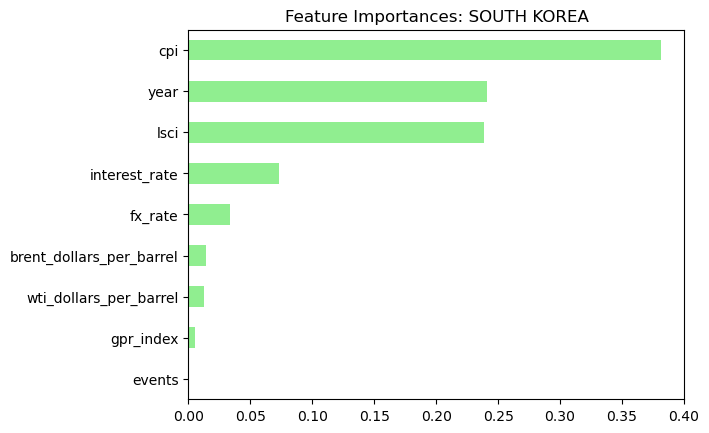

Features Importances: 
 cpi                         0.286604
interest_rate               0.278754
fx_rate                     0.213579
gpr_index                   0.082300
brent_dollars_per_barrel    0.073505
wti_dollars_per_barrel      0.065258
dtype: float64


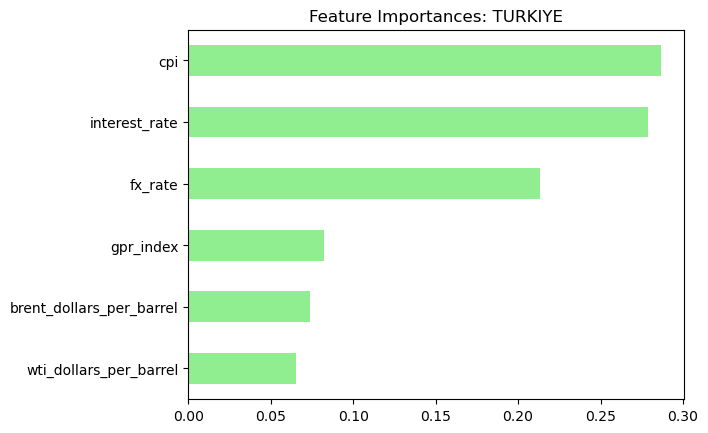

Features Importances: 
 cpi                         3.574714e-01
year                        2.679796e-01
lsci                        1.969117e-01
fx_rate                     1.169471e-01
interest_rate               3.301142e-02
brent_dollars_per_barrel    1.443941e-02
wti_dollars_per_barrel      1.002686e-02
gpr_index                   3.211994e-03
events                      4.359778e-07
dtype: float64


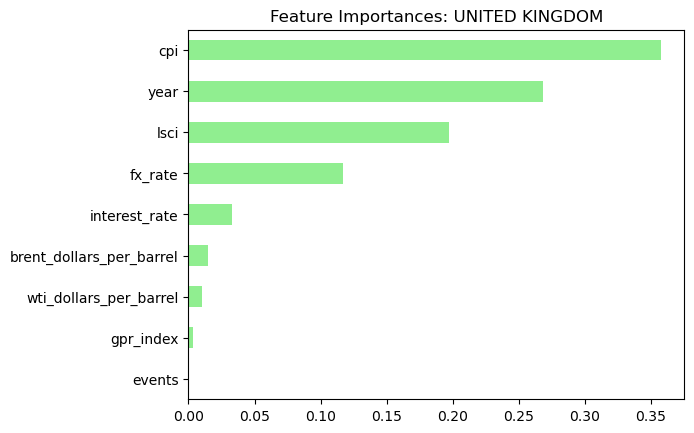

Features Importances: 
 cpi                         4.089104e-01
year                        2.737690e-01
fx_rate                     1.054546e-01
lsci                        8.570339e-02
interest_rate               6.184811e-02
brent_dollars_per_barrel    3.941845e-02
wti_dollars_per_barrel      1.592175e-02
gpr_index                   8.974203e-03
events                      1.140415e-07
dtype: float64


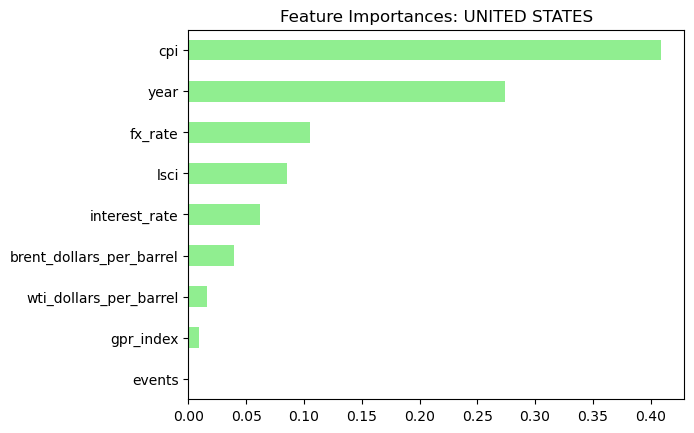

In [10]:
def show_feature_importance(country):
    # Create a Series of features importances
    importances_rf = pd.Series(globals()[f"{country}_rf_mdl"].feature_importances_,
                            index=globals()[f'{country}_selected_features']).sort_values()
    print(f'Features Importances: \n', importances_rf.sort_values(ascending=False))

    # Visualize
    importances_rf.plot(kind='barh', color='lightgreen')
    plt.title(f'Feature Importances: {country.upper().replace("_", " ")}')
    plt.show()

for country in country_list:
    show_feature_importance(country)

#### Accuracy and MSE

In [11]:
# Model Evaluation
for country in country_list:
    y_pred_train = globals()[f"{country}_rf_mdl"].predict(globals()[f"{country}_X_train"])
    y_pred_test = globals()[f"{country}_rf_mdl"].predict(globals()[f"{country}_X_test"])

    # Evaluate the train and test set MSE
    mse_train = mean_squared_error(globals()[f"{country}_y_train"], y_pred_train)
    mse_test = mean_squared_error(globals()[f"{country}_y_test"], y_pred_test)

    # Evaluate the train and test set RMSE
    rmse_train = np.sqrt(mse_train)
    print(f'Train set RMSE of {country.upper()} RF: {rmse_train:.2f}')
    rmse_test = np.sqrt(mse_test)
    print(f'Test set RMSE of {country.upper()} RF: {rmse_test:.2f}')
    print(f'Difference in RMSE between Train and Test data: {rmse_train - rmse_test:.2f} \n******')

    # Evaluate the train and test set r^2 score
    r_sqr_train = r2_score(globals()[f"{country}_y_train"], y_pred_train)
    print(f'Train set R-squared Score ({country}): {r_sqr_train:.4f}')
    r_sqr_test = r2_score(globals()[f"{country}_y_test"], y_pred_test)
    print(f'Test set R-squared Score ({country}): {r_sqr_test:.4f}')
    print(f'Difference in R-squared Score between Train and Test data: {r_sqr_train - r_sqr_test:.4f}\n')


Train set RMSE of BRAZIL RF: 238.22
Test set RMSE of BRAZIL RF: 680.81
Difference in RMSE between Train and Test data: -442.59 
******
Train set R-squared Score (brazil): 1.0000
Test set R-squared Score (brazil): 0.9999
Difference in R-squared Score between Train and Test data: 0.0001

Train set RMSE of CANADA RF: 86.73
Test set RMSE of CANADA RF: 173.08
Difference in RMSE between Train and Test data: -86.35 
******
Train set R-squared Score (canada): 1.0000
Test set R-squared Score (canada): 0.9999
Difference in R-squared Score between Train and Test data: 0.0000

Train set RMSE of JAPAN RF: 600.11
Test set RMSE of JAPAN RF: 1344.62
Difference in RMSE between Train and Test data: -744.51 
******
Train set R-squared Score (japan): 1.0000
Test set R-squared Score (japan): 0.9999
Difference in R-squared Score between Train and Test data: 0.0001

Train set RMSE of CHINA RF: 2478.25
Test set RMSE of CHINA RF: 5647.35
Difference in RMSE between Train and Test data: -3169.10 
******
Train se

### Impute missing variables
#### `fx_reserves`

In [12]:
for country in country_list:
    if globals()[f"{country}_null_df"].shape[0] == 0:
        print(f"{country.upper()} had no missing values for `fx_reserves`! Please, double check!")
        continue

    print(f"Predicting `fx_reserves` for {country}")
    # Subset for selected features
    globals()[f'{country}_null_df'] = globals()[f'{country}_null_df'][globals()[f"{country}_selected_features"]]

    # Impute 'fx_reserves' column
    globals()[f"{country}_inputed_df"] = globals()[f"{country}_null_df"].copy()
    globals()[f"{country}_inputed_df"]['fx_reserves'] = pd.Series(globals()[f"{country}_rf_mdl"].predict(globals()[f'{country}_null_df']))
    

Predicting `fx_reserves` for brazil
Predicting `fx_reserves` for canada
Predicting `fx_reserves` for japan
Predicting `fx_reserves` for china
Predicting `fx_reserves` for australia
GERMANY had no missing values for `fx_reserves`! Please, double check!
Predicting `fx_reserves` for india
Predicting `fx_reserves` for mexico
Predicting `fx_reserves` for france
ITALY had no missing values for `fx_reserves`! Please, double check!
Predicting `fx_reserves` for south_africa
RUSSIA had no missing values for `fx_reserves`! Please, double check!
Predicting `fx_reserves` for south_korea
TURKIYE had no missing values for `fx_reserves`! Please, double check!
Predicting `fx_reserves` for united_kingdom
Predicting `fx_reserves` for united_states


## Impute missing values and combine all datasets as a PySpark DF

In [13]:
# Efficiently combine per-country pandas DataFrames, then create a single Spark DataFrame
frames = []
for country in country_list:
    base_pd = globals().get(f"{country}_df")
    imputed_pd = globals().get(f"{country}_inputed_df")
    if base_pd is None:
        continue
    if imputed_pd is not None:
        merged_pd = pd.concat([base_pd, imputed_pd], ignore_index=True)
    else:
        merged_pd = base_pd.copy()
    merged_pd['country'] = country
    frames.append(merged_pd)

if len(frames) > 0:
    combined_pd = pd.concat(frames, ignore_index=True)
    
    cmbnd_df = spark.createDataFrame(combined_pd)
    cmbnd_df = cmbnd_df.repartition(10).cache()
    print("Combined Spark DataFrame rows:", cmbnd_df.count())
    
else:
    print("No per-country pandas frames found to combine.")

Combined Spark DataFrame rows: 60276


In [14]:

cmbnd_df = (
    cmbnd_df
    .withColumn('month',
                F.when(F.col('month_1')==1.0, F.lit(1))
                .when(F.col('month_2')==1.0, F.lit(2))
                .when(F.col('month_3')==1.0, F.lit(3))
                .when(F.col('month_4')==1.0, F.lit(4))
                .when(F.col('month_5')==1.0, F.lit(5))
                .when(F.col('month_6')==1.0, F.lit(6))
                .when(F.col('month_7')==1.0, F.lit(7))
                .when(F.col('month_8')==1.0, F.lit(8))
                .when(F.col('month_9')==1.0, F.lit(9))
                .when(F.col('month_10')==1.0, F.lit(10))
                .when(F.col('month_11')==1.0, F.lit(11))
                .when(F.col('month_12')==1.0, F.lit(12))
                .otherwise(F.lit(None))
                )
    .drop(*[f"month_{i}" for i in range(1, 13)], *[f"dow_{i}" for i in range(1, 8)])
)

In [15]:
# Bring the data back to the original joined_df DF
cols_exception = ['fx_reserves']
cols_to_join = [col for col in cmbnd_df.columns if col not in cols_exception+['month']]

final_df = (
    joined_df.alias('a')
    .join(cmbnd_df.drop('month').alias('b'),
          on=cols_to_join,
          how='left'
          )
    .select(*[F.coalesce(F.col(f"b.{col}"), F.col(f"a.{col}")).alias(col) for col in cols_exception],
            *cols_to_join)
)

In [16]:
final_df.show()

+---------------+----+----------------+-------+------------------------+----------------------+------+----+-------------------+------+---------+
|    fx_reserves|year|   interest_rate|fx_rate|brent_dollars_per_barrel|wti_dollars_per_barrel|events| cpi|          gpr_index|  lsci|  country|
+---------------+----+----------------+-------+------------------------+----------------------+------+----+-------------------+------+---------+
|49615.006092537|2006|5.72826086956522| 0.7519|                   67.57|                 71.42|     0|84.5|0.06284602731466293|141.65|australia|
|49615.006092537|2006|5.72826086956522| 0.7619|                   69.82|                 71.85|     0|84.5|0.06284602731466293|141.65|australia|
|49615.006092537|2006|5.72826086956522| 0.7577|                   69.88|                 71.35|     0|84.5|0.06284602731466293|141.65|australia|
|49615.006092537|2006|5.72826086956522| 0.7585|                   68.51|                 70.92|     0|84.5|0.06284602731466293|141

In [17]:
final_df.filter('country = "australia" and year = 2024 and month = 8').orderBy('date').show(30)

+-----------+----+-------------+-------+------------------------+----------------------+------+-----+-------------------+------+---------+
|fx_reserves|year|interest_rate|fx_rate|brent_dollars_per_barrel|wti_dollars_per_barrel|events|  cpi|          gpr_index|  lsci|  country|
+-----------+----+-------------+-------+------------------------+----------------------+------+-----+-------------------+------+---------+
|       NULL|2024|         4.35| 0.6522|                   81.37|                 77.74|     0|96.49|0.17090770602226257|139.32|australia|
|       NULL|2024|         4.35| 0.6528|                   78.35|                 74.99|     0|96.49|0.17090770602226257|139.32|australia|
|       NULL|2024|         4.35| 0.6488|                   77.51|                 74.46|     0|96.49|0.17090770602226257|139.32|australia|
|       NULL|2024|         4.35| 0.6519|                   76.62|                  74.6|     0|96.49|0.17090770602226257|139.32|australia|
|       NULL|2024|         

In [18]:
bef_impute = joined_df.filter(reduce(lambda x, y: x|y, [F.col(col).isNull() for col in joined_df.columns])).count()
aft_impute = final_df.filter(reduce(lambda x, y: x|y, [F.col(col).isNull() for col in final_df.columns])).count()

print(f"Rows with Missing values before imputation: {bef_impute}\nRows with Missing values after imputation: {aft_impute}")

Rows with Missing values before imputation: 4680
Rows with Missing values after imputation: 1448


In [19]:
final_df.toPandas().to_csv(f"{out_path}/final_df.csv")